In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append(f"./../")
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
from src.misc import *

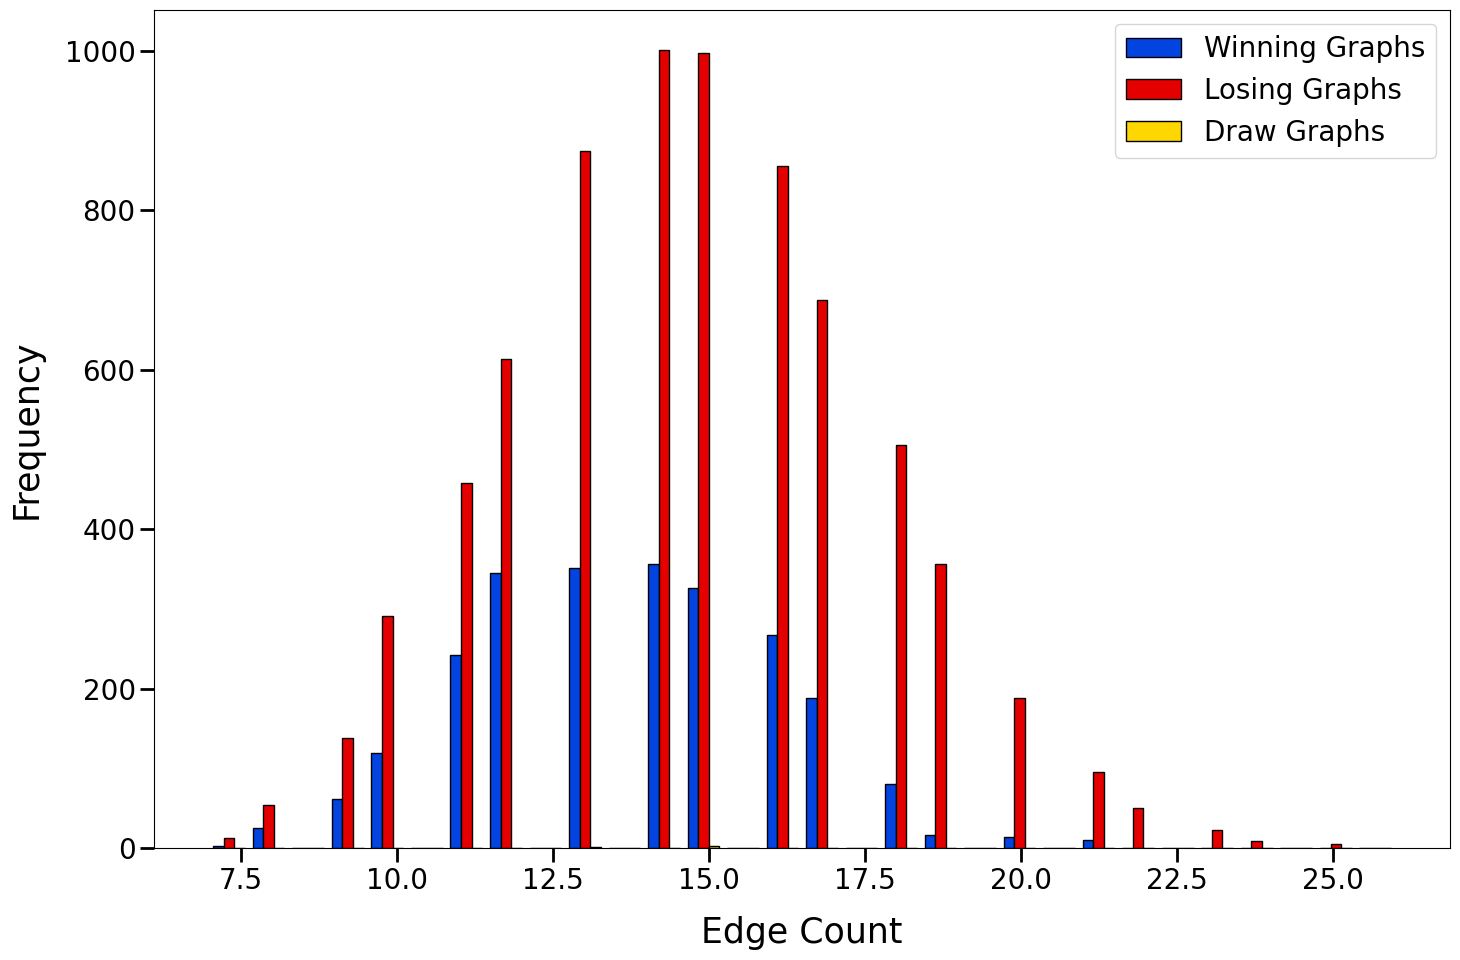

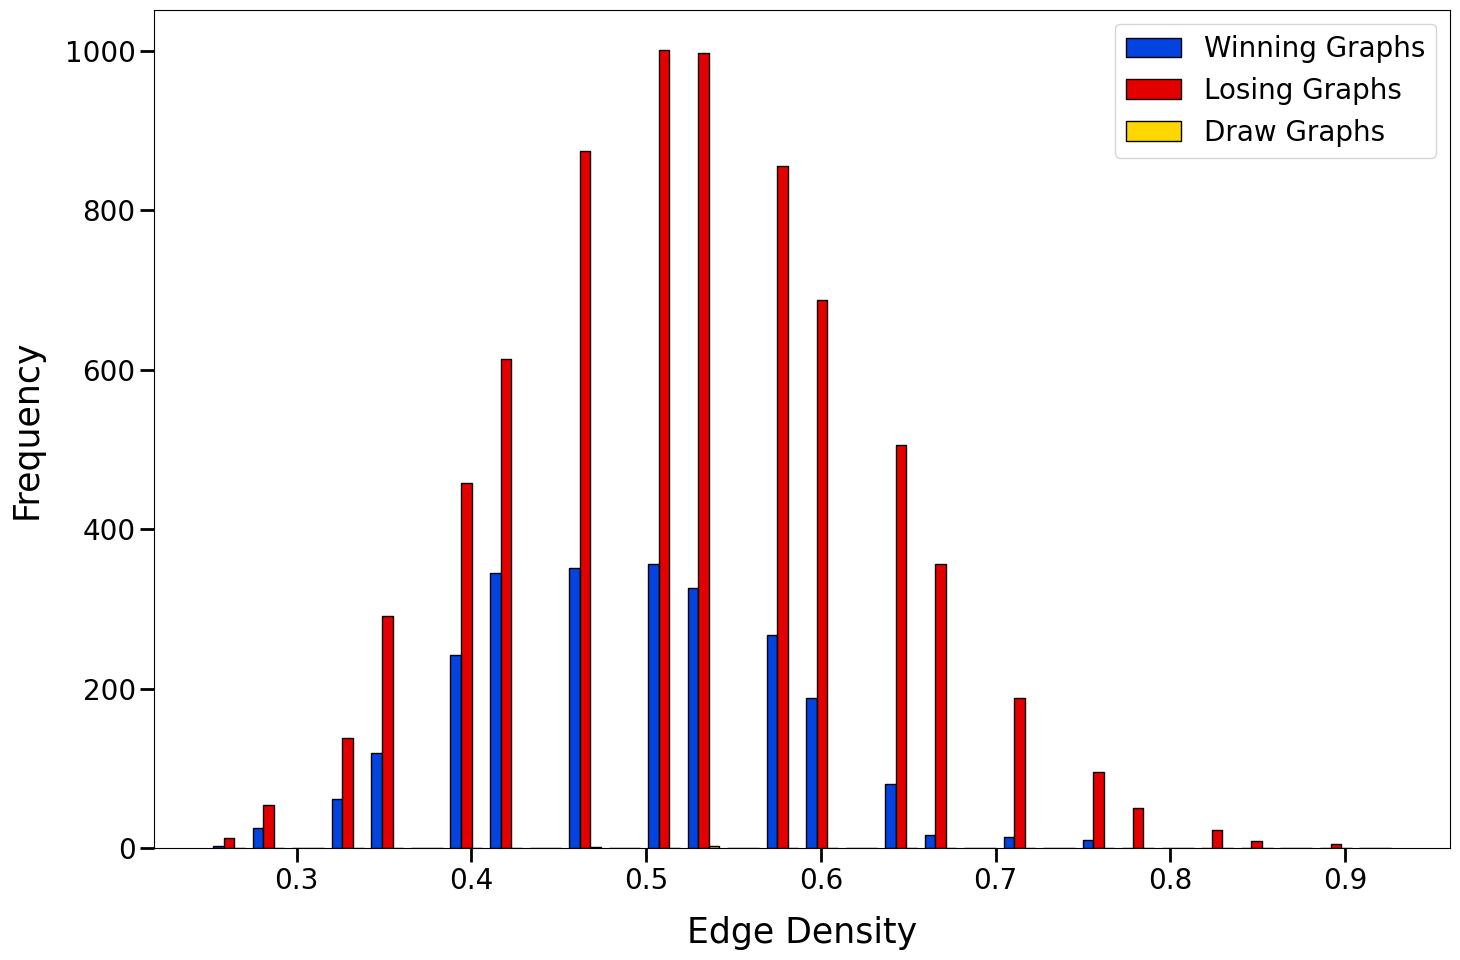

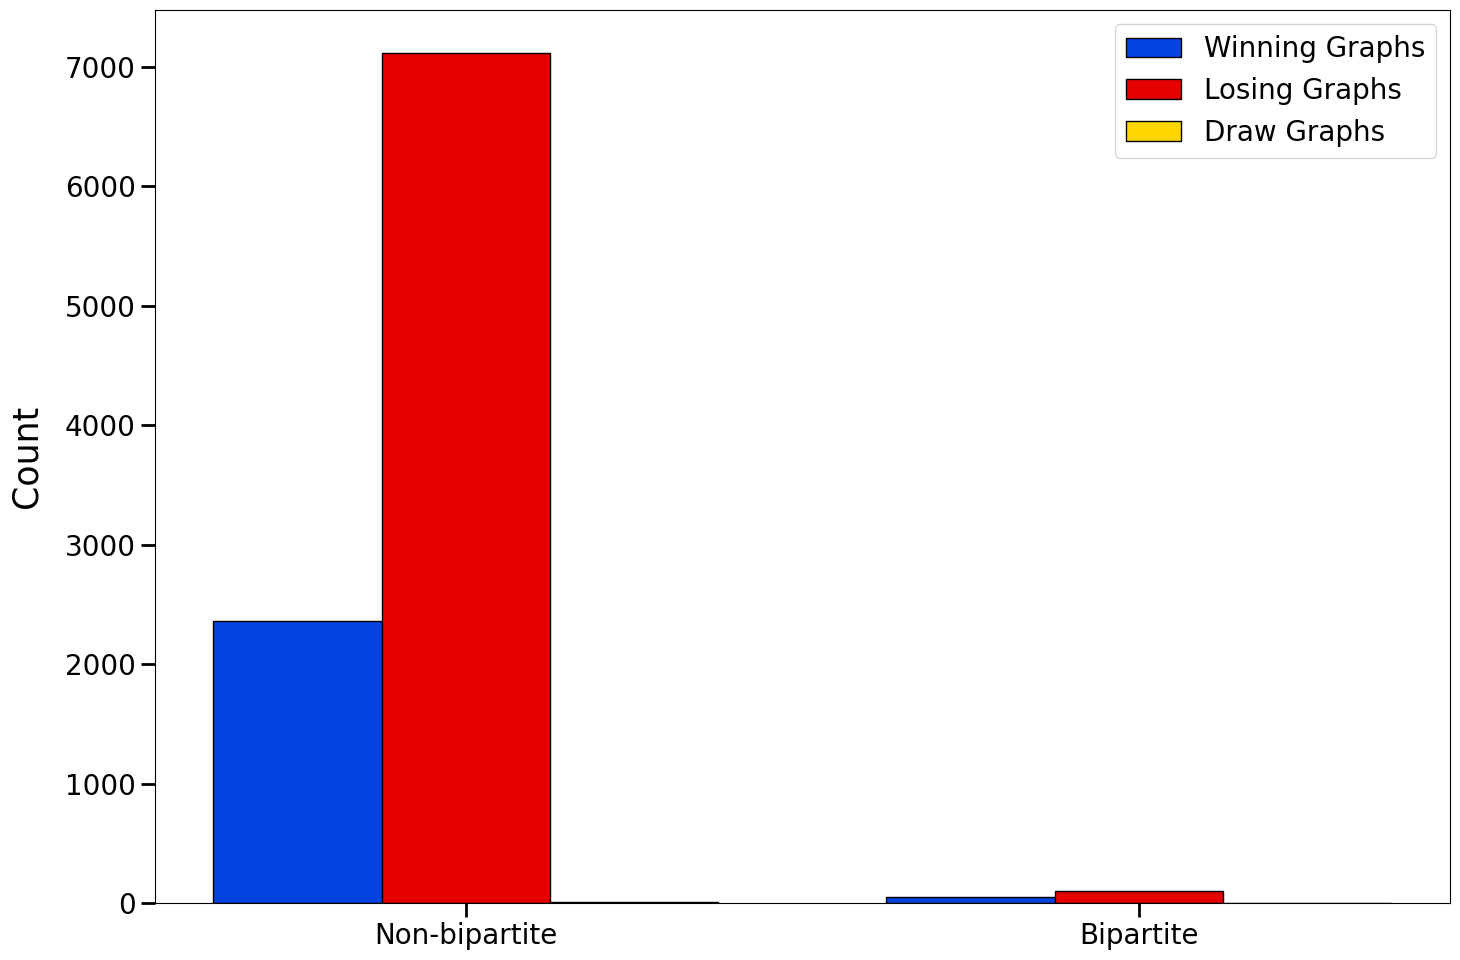

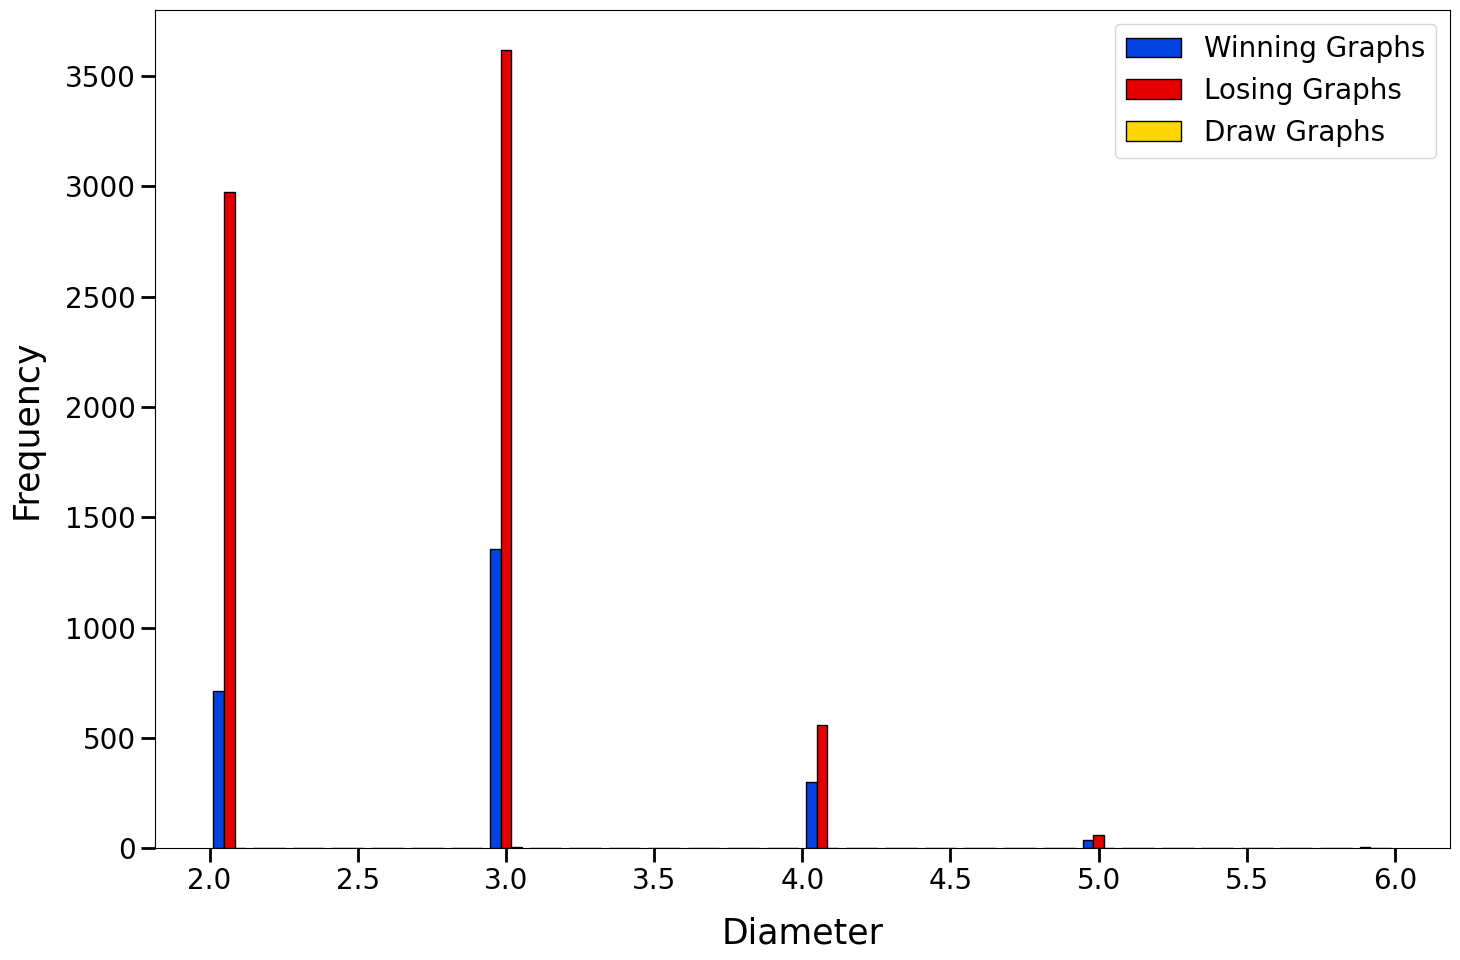

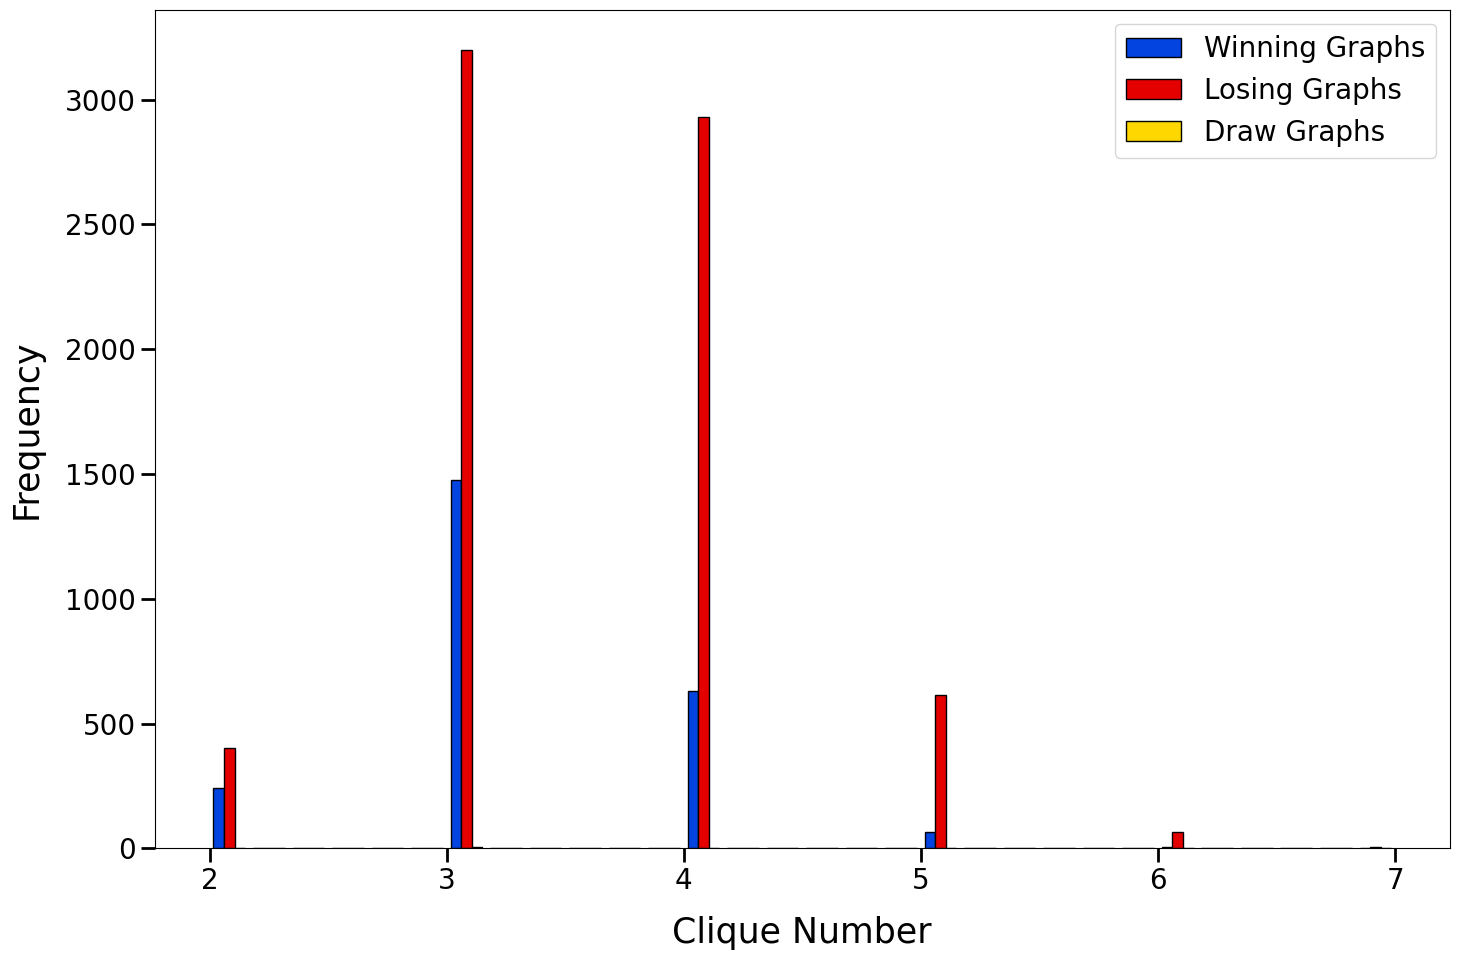

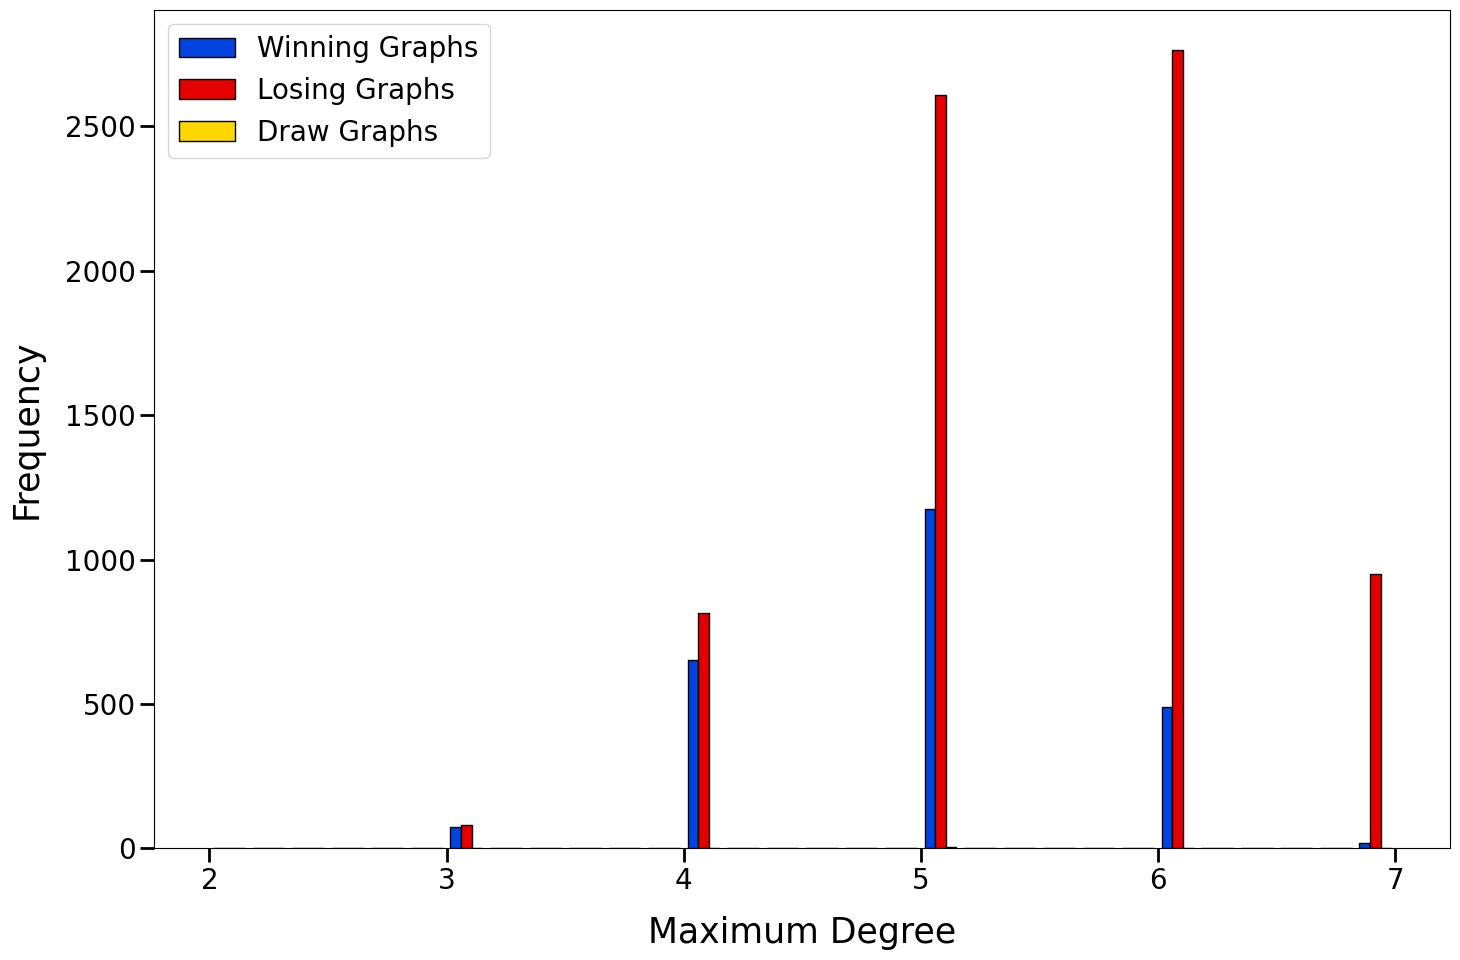

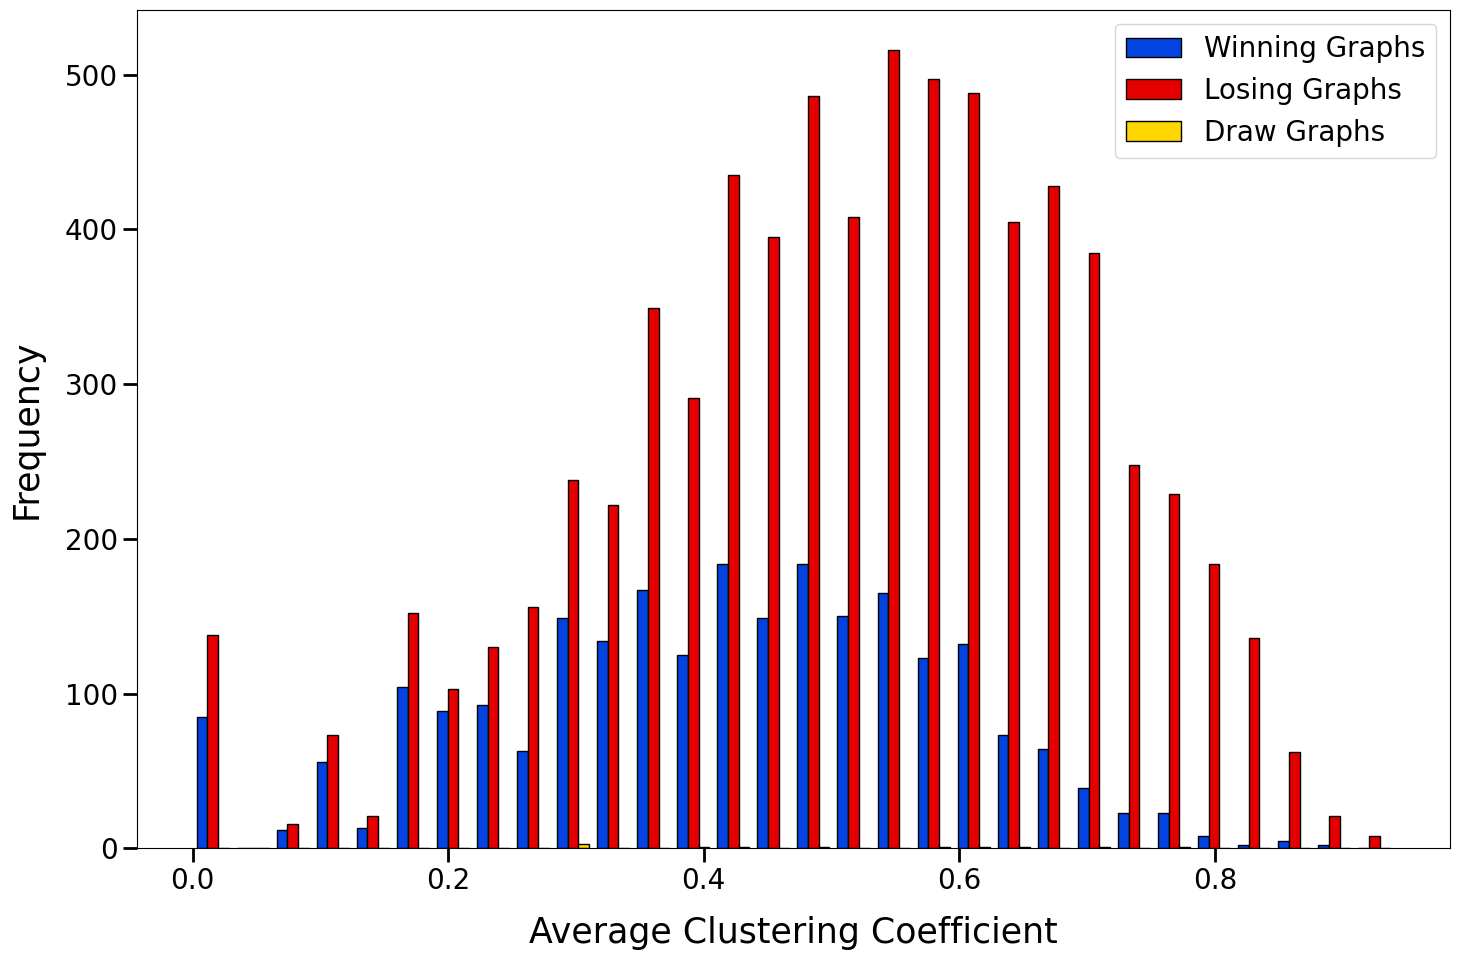

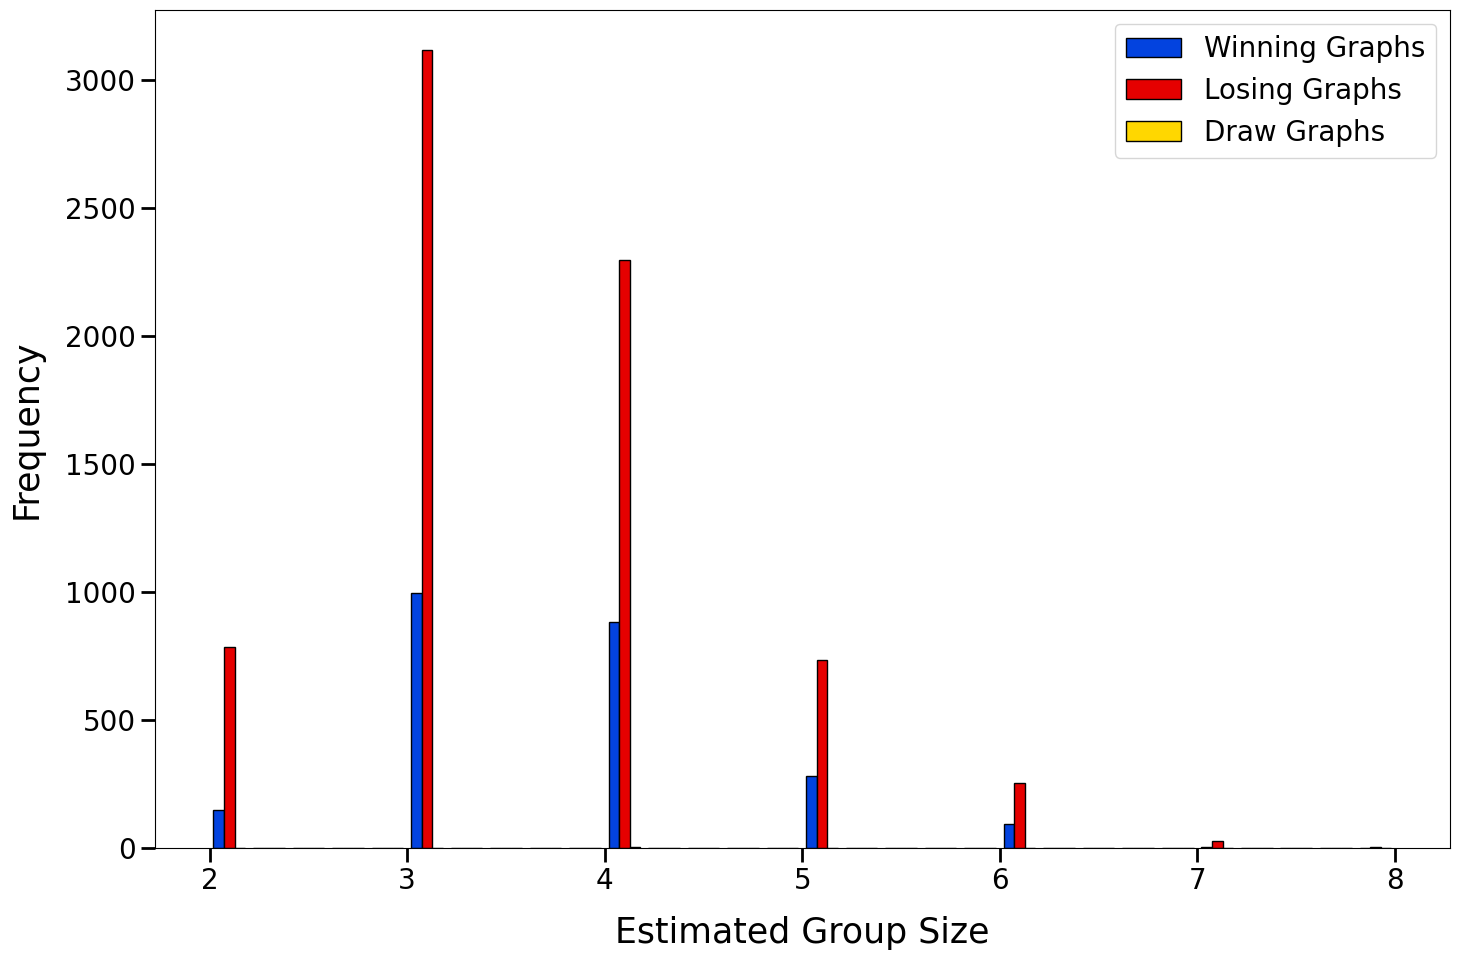

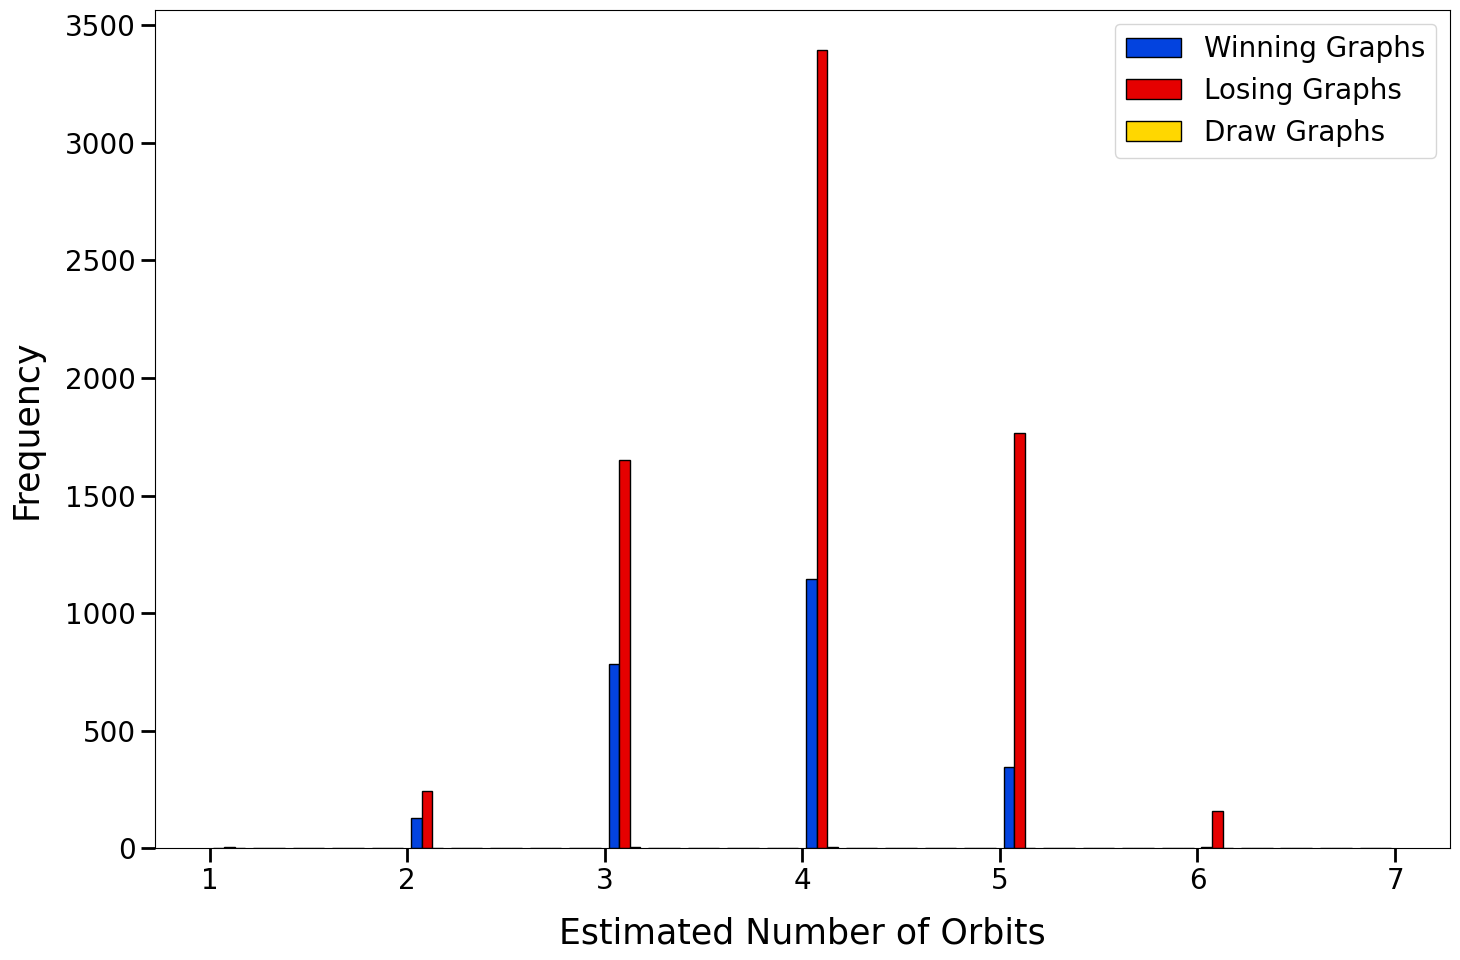

In [2]:
# Define colors for three categories
WINNING_COLOR = '#0343df'  # blue
LOSING_COLOR = '#e50000'   # red
DRAW_COLOR = '#ffd700'     # yellow

# Set plot parameters
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['axes.titlesize'] = 25
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20

# Collect properties for all three categories
#n_vertices = 2**4
n_vertices = 2**3

# winning_props = collect_graph_properties(f'../data/graphs/negative_{n_vertices}cgraphs.g6', n_vertices)
# losing_props = collect_graph_properties(f'../data/graphs/positive_{n_vertices}cgraphs.g6', n_vertices)
# draw_props = collect_graph_properties(f'../data/graphs/zero_{n_vertices}cgraphs.g6', n_vertices)

cat = '_both_8v'

winning_props = collect_graph_properties(f'../data/graphs/win{cat}.g6', n_vertices)
losing_props = collect_graph_properties(f'../data/graphs/lose{cat}.g6', n_vertices)
draw_props = collect_graph_properties(f'../data/graphs/draw{cat}.g6', n_vertices)

plots_folder = '../data/plots/'

def plot_comparison_histogram(win_data, lose_data, draw_data, title, xlabel, ylabel, filename):
    plt.figure(figsize=(15, 10))
    
    all_data = np.concatenate([win_data, lose_data, draw_data])
    bins = np.histogram(all_data, bins=30)[1]  # Get the bin edges
    
    plt.hist([win_data, lose_data, draw_data], bins=bins, 
             label=['Winning Graphs', 'Losing Graphs', 'Draw Graphs'],
             color=[WINNING_COLOR, LOSING_COLOR, DRAW_COLOR], 
             histtype='bar', edgecolor='black')
    
    plt.title(title, pad=20)
    plt.xlabel(xlabel, labelpad=15)
    plt.ylabel(ylabel, labelpad=15)
    plt.legend(prop={'size': 20})
    plt.tick_params(axis='both', which='major', labelsize=20, length=10, width=2)
    plt.tick_params(axis='both', which='minor', labelsize=15, length=5, width=1)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

def plot_comparison_bar(win_data, lose_data, draw_data, title, xlabel, ylabel, filename):
    plt.figure(figsize=(15, 10))
    
    x = np.arange(2)
    width = 0.25  # Reduced width to fit three bars
    
    plt.bar(x - width, [win_data[False], win_data[True]], width, 
           label='Winning Graphs', color=WINNING_COLOR, edgecolor='black')
    plt.bar(x, [lose_data[False], lose_data[True]], width, 
           label='Losing Graphs', color=LOSING_COLOR, edgecolor='black')
    plt.bar(x + width, [draw_data[False], draw_data[True]], width, 
           label='Draw Graphs', color=DRAW_COLOR, edgecolor='black')
    
    plt.title(title, pad=20)
    plt.xlabel(xlabel, labelpad=15)
    plt.ylabel(ylabel, labelpad=15)
    plt.xticks(x, ['Non-bipartite', 'Bipartite'], rotation=0)
    plt.legend(prop={'size': 20})
    plt.tick_params(axis='both', which='major', labelsize=20, length=10, width=2)
    plt.tick_params(axis='both', which='minor', labelsize=15, length=5, width=1)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Generate all comparison plots
plot_comparison_histogram(
    winning_props['edge_counts'], 
    losing_props['edge_counts'],
    draw_props['edge_counts'],
    '', 'Edge Count', 'Frequency', 
    #plots_folder+f'edge_counts_comparison_{n_vertices}c.pdf'
    plots_folder+f'edge_counts_comparison{cat}.pdf'
)

plot_comparison_histogram(
    winning_props['edge_densities'], 
    losing_props['edge_densities'],
    draw_props['edge_densities'],
    '', 'Edge Density', 'Frequency', 
    # plots_folder+f'edge_density_comparison_{n_vertices}c.pdf'
    plots_folder+f'edge_density_comparison{cat}.pdf'
)

plot_comparison_bar(
    winning_props['bipartite_counts'],
    losing_props['bipartite_counts'],
    draw_props['bipartite_counts'],
    '', '', 'Count',
    # plots_folder+f'bipartiteness_comparison_{n_vertices}c.pdf'
    plots_folder+f'bipartiteness_comparison{cat}.pdf'
)

plot_comparison_histogram(
    winning_props['diameters'],
    losing_props['diameters'],
    draw_props['diameters'],
    '', 'Diameter', 'Frequency',
    #plots_folder+f'diameters_comparison_{n_vertices}c.pdf'
    plots_folder+f'diameters_comparison{cat}.pdf'
)

plot_comparison_histogram(
    winning_props['clique_numbers'],
    losing_props['clique_numbers'],
    draw_props['clique_numbers'],
    '', 'Clique Number', 'Frequency',
    # plots_folder+f'clique_numbers_comparison_{n_vertices}c.pdf'
    plots_folder+f'clique_numbers_comparison{cat}.pdf'
)

plot_comparison_histogram(
    winning_props['max_degrees'],
    losing_props['max_degrees'],
    draw_props['max_degrees'],
    '', 'Maximum Degree', 'Frequency',
    # plots_folder+f'max_degrees_comparison_{n_vertices}c.pdf'
    plots_folder+f'max_degrees_comparison{cat}.pdf'
)

plot_comparison_histogram(
    winning_props['clustering_coefficients'],
    losing_props['clustering_coefficients'],
    draw_props['clustering_coefficients'],
    '', 'Average Clustering Coefficient', 'Frequency',
    # plots_folder+f'clustering_coefficients_comparison_{n_vertices}c.pdf'
    plots_folder+f'clustering_coefficients_comparison{cat}.pdf'
)

plot_comparison_histogram(
    winning_props['group_sizes'],
    losing_props['group_sizes'],
    draw_props['group_sizes'],
    '', 'Estimated Group Size', 'Frequency',
    # plots_folder+f'group_sizes_comparison_{n_vertices}c.pdf'
    plots_folder+f'group_sizes_comparison{cat}.pdf'
)

plot_comparison_histogram(
    winning_props['orbit_counts'],
    losing_props['orbit_counts'],
    draw_props['orbit_counts'],
    '', 'Estimated Number of Orbits', 'Frequency',
    # plots_folder+f'orbit_counts_comparison_{n_vertices}c.pdf'
    plots_folder+f'orbit_counts_comparison{cat}.pdf'
)

In [3]:
# Print statistics for all three groups
for group_name, props in [("Winning", winning_props), 
                         ("Losing", losing_props), 
                         ("Draw", draw_props)]:
    
    try: 
        print(f"\n{group_name} Graphs Statistics:")
        print(f"Total graphs processed: {len(props['edge_counts'])}")
        print(f"Edge count - Min: {min(props['edge_counts'])}, Max: {max(props['edge_counts'])}, Mean: {np.mean(props['edge_counts']):.2f}")
        print(f"Edge density - Min: {min(props['edge_densities']):.4f}, Max: {max(props['edge_densities']):.4f}, Mean: {np.mean(props['edge_densities']):.4f}")
        print(f"Bipartite graphs: {props['bipartite_counts'][True]}, Non-bipartite graphs: {props['bipartite_counts'][False]}")
        print(f"Diameter - Min: {min(props['diameters'])}, Max: {max(props['diameters'])}, Mean: {np.mean(props['diameters']):.2f}")
        print(f"Clique number - Min: {min(props['clique_numbers'])}, Max: {max(props['clique_numbers'])}, Mean: {np.mean(props['clique_numbers']):.2f}")
        print(f"Maximum degree - Min: {min(props['max_degrees'])}, Max: {max(props['max_degrees'])}, Mean: {np.mean(props['max_degrees']):.2f}")
        print(f"Clustering coefficient - Min: {min(props['clustering_coefficients'])}, Max: {max(props['clustering_coefficients'])}, Mean: {np.mean(props['clustering_coefficients']):.2f}")
        print(f"Estimated group size - Min: {min(props['group_sizes'])}, Max: {max(props['group_sizes'])}, Mean: {np.mean(props['group_sizes']):.2f}")
        print(f"Estimated orbit count - Min: {min(props['orbit_counts'])}, Max: {max(props['orbit_counts'])}, Mean: {np.mean(props['orbit_counts']):.2f}")
    except: continue


Winning Graphs Statistics:
Total graphs processed: 2416
Edge count - Min: 7, Max: 24, Mean: 13.70
Edge density - Min: 0.2500, Max: 0.8571, Mean: 0.4894
Bipartite graphs: 50, Non-bipartite graphs: 2366
Diameter - Min: 2, Max: 6, Mean: 2.87
Clique number - Min: 2, Max: 6, Mean: 3.22
Maximum degree - Min: 2, Max: 7, Mean: 4.89
Clustering coefficient - Min: 0.0, Max: 0.9047619047619048, Mean: 0.42
Estimated group size - Min: 2, Max: 8, Mean: 3.67
Estimated orbit count - Min: 1, Max: 6, Mean: 3.71

Losing Graphs Statistics:
Total graphs processed: 7220
Edge count - Min: 7, Max: 26, Mean: 14.75
Edge density - Min: 0.2500, Max: 0.9286, Mean: 0.5267
Bipartite graphs: 99, Non-bipartite graphs: 7121
Diameter - Min: 2, Max: 6, Mean: 2.68
Clique number - Min: 2, Max: 7, Mean: 3.55
Maximum degree - Min: 3, Max: 7, Mean: 5.51
Clustering coefficient - Min: 0.0, Max: 0.9404761904761905, Mean: 0.51
Estimated group size - Min: 2, Max: 8, Mean: 3.54
Estimated orbit count - Min: 1, Max: 7, Mean: 3.99

Dr